In [2]:

print("Path to dataset files:", path)import kagglehub

# Download latest version
path = kagglehub.dataset_download("uciml/default-of-credit-card-clients-dataset")


100%|██████████| 0.98M/0.98M [00:00<00:00, 86.6MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/uciml/default-of-credit-card-clients-dataset/versions/1


In [3]:
import os

# List files in the downloaded directory
files_in_path = os.listdir(path)
print("Files in the dataset directory:", files_in_path)

Files in the dataset directory: ['UCI_Credit_Card.csv']


Please examine the output from the previous cell to determine the exact name of the CSV file. Once you know the filename, you can use the following code (replace `"your_csv_file.csv"` with the actual filename) to load the data into a pandas DataFrame and display the first 5 rows.

In [5]:
import pandas as pd

# Replace 'your_csv_file.csv' with the actual CSV filename from the output above
csv_file_name = "UCI_Credit_Card.csv"
full_csv_path = os.path.join(path, csv_file_name)

df = pd.read_csv(full_csv_path)
display(df.head())

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [6]:
num_rows, num_columns = df.shape
print(f"The DataFrame has {num_rows} rows and {num_columns} columns.")

The DataFrame has 30000 rows and 25 columns.


# Task
Perform data preprocessing on the `df` DataFrame, which includes data cleaning, handling missing values, encoding categorical variables, and scaling numerical features.

## Data Cleaning

### Subtask:
Identify and handle duplicate rows and inspect data types for potential reformatting if needed.


**Reasoning**:
First, I will identify and remove any duplicate rows from the DataFrame `df` to ensure data integrity and then print the shape of the DataFrame to show the number of rows and columns after duplicate removal.



In [7]:
initial_rows = df.shape[0]
df.drop_duplicates(inplace=True)
duplicate_rows_removed = initial_rows - df.shape[0]

print(f"Number of duplicate rows removed: {duplicate_rows_removed}")
print(f"DataFrame shape after removing duplicates: {df.shape}")

Number of duplicate rows removed: 0
DataFrame shape after removing duplicates: (30000, 25)


**Reasoning**:
Now that duplicate rows have been handled, I will inspect the data types of all columns in the DataFrame to identify any columns that might need reformatting.



In [8]:
print("Data types of columns:\n")
df.info()

Data types of columns:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AM

## Missing Value Imputation

### Subtask:
Identify columns with missing values and apply appropriate imputation strategies.


**Reasoning**:
I will check for missing values in the DataFrame `df` using the `.isnull().sum()` methods to identify columns that require imputation and print the results.



In [9]:
missing_values = df.isnull().sum()

print("Missing values per column:")
print(missing_values[missing_values > 0])

if missing_values.sum() == 0:
    print("\nNo missing values found in the DataFrame. No imputation is needed.")

Missing values per column:
Series([], dtype: int64)

No missing values found in the DataFrame. No imputation is needed.


## Categorical Variable Encoding

### Subtask:
Detect categorical columns and apply suitable encoding techniques such as One-Hot Encoding, Label Encoding, or Target Encoding to convert them into numerical representations.


**Reasoning**:
To begin categorical variable encoding, I will identify potential categorical columns by examining the unique values and their counts for columns that are likely to represent categories, even if they are stored as integers. This helps in understanding the distinct categories and assessing the cardinality of each column.



In [10]:
categorical_cols = ['SEX', 'EDUCATION', 'MARRIAGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

print("Unique values and their counts for potential categorical columns:")
for col in categorical_cols:
    print(f"\nColumn '{col}':")
    print(df[col].value_counts().sort_index())


Unique values and their counts for potential categorical columns:

Column 'SEX':
SEX
1    11888
2    18112
Name: count, dtype: int64

Column 'EDUCATION':
EDUCATION
0       14
1    10585
2    14030
3     4917
4      123
5      280
6       51
Name: count, dtype: int64

Column 'MARRIAGE':
MARRIAGE
0       54
1    13659
2    15964
3      323
Name: count, dtype: int64

Column 'PAY_0':
PAY_0
-2     2759
-1     5686
 0    14737
 1     3688
 2     2667
 3      322
 4       76
 5       26
 6       11
 7        9
 8       19
Name: count, dtype: int64

Column 'PAY_2':
PAY_2
-2     3782
-1     6050
 0    15730
 1       28
 2     3927
 3      326
 4       99
 5       25
 6       12
 7       20
 8        1
Name: count, dtype: int64

Column 'PAY_3':
PAY_3
-2     4085
-1     5938
 0    15764
 1        4
 2     3819
 3      240
 4       76
 5       21
 6       23
 7       27
 8        3
Name: count, dtype: int64

Column 'PAY_4':
PAY_4
-2     4348
-1     5687
 0    16455
 1        2
 2     3159
 3      

**Reasoning**:
Based on the analysis of unique values and their counts, `EDUCATION` and `MARRIAGE` columns are nominal categorical variables, and `PAY_0` through `PAY_6` columns, despite having an inherent order, contain special values (-2, -1, 0) that might not fit a linear ordinal scale and are better treated as nominal for robust encoding. Therefore, One-Hot Encoding is the most suitable strategy for these columns to avoid imposing an incorrect ordinal relationship. `SEX` is already binary (1,2) and can be left as is.



In [11]:
one_hot_encode_cols = ['EDUCATION', 'MARRIAGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

# Apply One-Hot Encoding
df = pd.get_dummies(df, columns=one_hot_encode_cols, prefix=one_hot_encode_cols)

print("DataFrame shape after One-Hot Encoding:", df.shape)
print("First 5 rows of the DataFrame after One-Hot Encoding:")
display(df.head())

DataFrame shape after One-Hot Encoding: (30000, 92)
First 5 rows of the DataFrame after One-Hot Encoding:


,ID,LIMIT_BAL,SEX,AGE,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,...,PAY_6_-2,PAY_6_-1,PAY_6_0,PAY_6_2,PAY_6_3,PAY_6_4,PAY_6_5,PAY_6_6,PAY_6_7,PAY_6_8
0,1,20000.0,2,24,3913.0,3102.0,689.0,0.0,0.0,0.0,...,True,False,False,False,False,False,False,False,False,False
1,2,120000.0,2,26,2682.0,1725.0,2682.0,3272.0,3455.0,3261.0,...,False,False,False,True,False,False,False,False,False,False
2,3,90000.0,2,34,29239.0,14027.0,13559.0,14331.0,14948.0,15549.0,...,False,False,True,False,False,False,False,False,False,False
3,4,50000.0,2,37,46990.0,48233.0,49291.0,28314.0,28959.0,29547.0,...,False,False,True,False,False,False,False,False,False,False
4,5,50000.0,1,57,8617.0,5670.0,35835.0,20940.0,19146.0,19131.0,...,False,False,True,False,False,False,False,False,False,False


**Reasoning**:
Now that categorical variables have been encoded, I need to prepare for numerical feature scaling. I will identify all numerical columns that are not 'ID' and are not the one-hot encoded columns or the target variable, and then display their descriptive statistics to understand their distributions before scaling.



In [12]:
import numpy as np

# Identify numerical columns for scaling, excluding 'ID' and already one-hot encoded columns, and the target variable.
# The 'default.payment.next.month' column is the target variable and should not be scaled.

# Get all column names
all_columns = df.columns.tolist()

# Exclude 'ID', the target variable, and the one-hot encoded columns (which now have prefixes)
one_hot_encoded_prefixes = [col + '_' for col in one_hot_encode_cols]

columns_to_exclude = ['ID', 'default.payment.next.month'] + [col for col in all_columns if any(col.startswith(prefix) for prefix in one_hot_encoded_prefixes)]

# Identify remaining numerical columns
numerical_cols_for_scaling = [col for col in all_columns if col not in columns_to_exclude and pd.api.types.is_numeric_dtype(df[col])]

print("Numerical columns identified for scaling:", numerical_cols_for_scaling)
print("\nDescriptive statistics for numerical columns before scaling:")
display(df[numerical_cols_for_scaling].describe())

Numerical columns identified for scaling: ['LIMIT_BAL', 'SEX', 'AGE', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']

Descriptive statistics for numerical columns before scaling:


,LIMIT_BAL,SEX,AGE,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000
mean,167484.322667,1.603733,35.485500,51223.330900,49179.075167,4.701315e+04,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567
std,129747.661567,0.489129,9.217904,73635.860576,71173.768783,6.934939e+04,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775
min,10000.000000,1.000000,21.000000,-165580.000000,-69777.000000,-1.572640e+05,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000
25%,50000.000000,1.000000,28.000000,3558.750000,2984.750000,2.666250e+03,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000
50%,140000.000000,2.000000,34.000000,22381.500000,21200.000000,2.008850e+04,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000
75%,240000.000000,2.000000,41.000000,67091.000000,64006.250000,6.016475e+04,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000
max,1000000.000000,2.000000,79.000000,964511.000000,983931.000000,1.664089e+06,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000


**Reasoning**:
Now that the numerical columns for scaling have been identified, I will apply `StandardScaler` to these columns to standardize their values. This will transform the data to have a mean of 0 and a standard deviation of 1, which is important for many machine learning algorithms.



In [13]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Apply scaling to the identified numerical columns
df[numerical_cols_for_scaling] = scaler.fit_transform(df[numerical_cols_for_scaling])

print("Descriptive statistics for numerical columns after scaling:")
display(df[numerical_cols_for_scaling].describe())

Descriptive statistics for numerical columns after scaling:


,LIMIT_BAL,SEX,AGE,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
count,3.000000e+04,3.000000e+04,3.000000e+04,3.000000e+04,3.000000e+04,3.000000e+04,3.000000e+04,3.000000e+04,3.000000e+04,3.000000e+04,3.000000e+04,3.000000e+04,3.000000e+04,3.000000e+04,3.000000e+04
mean,-6.063298e-17,2.330580e-16,-1.856885e-16,-1.231607e-17,-3.789561e-17,6.252776e-17,5.873820e-17,-2.368476e-17,1.136868e-17,-4.736952e-18,1.373716e-17,2.084259e-17,1.800042e-17,-1.965835e-17,-1.788199e-17
std,1.000017e+00,1.000017e+00,1.000017e+00,1.000017e+00,1.000017e+00,1.000017e+00,1.000017e+00,1.000017e+00,1.000017e+00,1.000017e+00,1.000017e+00,1.000017e+00,1.000017e+00,1.000017e+00,1.000017e+00
min,-1.213794e+00,-1.234323e+00,-1.571479e+00,-2.944312e+00,-1.671375e+00,-2.945672e+00,-3.315048e+00,-2.000874e+00,-6.355247e+00,-3.419416e-01,-2.569895e-01,-2.968013e-01,-3.080626e-01,-3.141361e-01,-2.933821e-01
25%,-9.054983e-01,-1.234323e+00,-8.120745e-01,-6.473120e-01,-6.490466e-01,-6.394814e-01,-6.363293e-01,-6.340600e-01,-6.316338e-01,-2.815661e-01,-2.208358e-01,-2.746506e-01,-2.891680e-01,-2.976091e-01,-2.867584e-01
50%,-2.118326e-01,8.101607e-01,-1.611565e-01,-3.916884e-01,-3.931159e-01,-3.882529e-01,-3.763451e-01,-3.652683e-01,-3.660725e-01,-2.151530e-01,-1.697952e-01,-1.945673e-01,-2.123132e-01,-2.159561e-01,-2.090042e-01
75%,5.589071e-01,8.101607e-01,5.982479e-01,2.154919e-01,2.083271e-01,1.896457e-01,1.747667e-01,1.624955e-01,1.733997e-01,-3.970176e-02,-3.998021e-02,-4.093230e-02,-5.188511e-02,-5.026084e-02,-6.837436e-02
max,6.416528e+00,8.101607e-01,4.720729e+00,1.240296e+01,1.313360e+01,2.331820e+01,1.318669e+01,1.458743e+01,1.549528e+01,5.239921e+01,7.284299e+01,5.059528e+01,3.933218e+01,2.760363e+01,2.944510e+01


## Final Task

### Subtask:
Summarize the data preprocessing steps performed, including data cleaning, missing value handling, categorical encoding, and numerical scaling.


**Interprétation des Histograms**: Les histograms montrent la distribution de chaque variable numérique. Par exemple, pour 'LIMIT_BAL', nous pouvons observer que la distribution est asymétrique vers la droite, indiquant que la plupart des clients ont des limites de crédit plus faibles, avec quelques-uns ayant des limites très élevées. Les variables 'BILL_AMT' et 'PAY_AMT' affichent également des distributions asymétriques, suggérant que la majorité des montants de facture et de paiement sont concentrés vers des valeurs plus petites. 'AGE' semble suivre une distribution plus normale, centrée autour de 30-40 ans. Les variables 'SEX', 'EDUCATION' et 'MARRIAGE' étant des variables catégorielles encodées en numérique, leurs distributions reflètent les proportions des différentes catégories.

**Interprétation des Boxplots**: Les boxplots complètent les histograms en visualisant la médiane, les quartiles et les valeurs aberrantes (outliers) pour chaque variable numérique. Pour 'LIMIT_BAL' et les 'BILL_AMT', les boxplots confirment la présence de nombreuses valeurs aberrantes vers le haut, indiquant des clients avec des limites de crédit et des montants de facture exceptionnellement élevés. Les variables 'PAY_AMT' montrent également un grand nombre d'outliers positifs, signifiant que certains clients effectuent des paiements très importants. Les boîtes de 'AGE' sont relativement symétriques, avec quelques outliers aux extrémités. Les boxplots pour 'SEX', 'EDUCATION' et 'MARRIAGE' (bien que traités numériquement pour la visualisation ici) illustrent la concentration des données autour de leurs valeurs discrètes.

**Interprétation de la Matrice de Corrélation**: La heatmap de corrélation révèle les relations linéaires entre les variables numériques. On observe des corrélations positives très fortes (proches de 1) entre les variables 'BILL_AMT' (par exemple, `BILL_AMT1` est fortement corrélé avec `BILL_AMT2`, `BILL_AMT3`, etc.), ce qui est attendu car les montants des factures d'un mois à l'autre sont souvent liés. De même, il y a des corrélations modérées entre 'LIMIT_BAL' et 'BILL_AMT', ce qui est logique car des limites de crédit plus élevées peuvent entraîner des factures plus élevées. Les variables 'PAY_AMT' montrent des corrélations plus faibles entre elles et avec les 'BILL_AMT', ce qui suggère des comportements de paiement plus variés. Des corrélations négatives faibles ou nulles sont visibles entre 'AGE' et la plupart des autres variables, indiquant que l'âge n'a pas une forte relation linéaire avec les montants de crédit, de facture ou de paiement.

**Raisonnement**:
Je vais créer de nouvelles caractéristiques qui agrègent les informations des montants de facture et de paiement sur les six mois, ainsi qu'un ratio d'utilisation de la limite de crédit. Ces caractéristiques agrégées peuvent fournir une meilleure représentation du comportement financier d'un client et pourraient être de puissants prédicteurs de défaut.

In [17]:
# Create AVG_BILL_AMT (Average Bill Amount for the last 6 months)
bill_amt_cols = ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']
df['AVG_BILL_AMT'] = df[bill_amt_cols].mean(axis=1)

# Create AVG_PAY_AMT (Average Payment Amount for the last 6 months)
pay_amt_cols = ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']
df['AVG_PAY_AMT'] = df[pay_amt_cols].mean(axis=1)

# Create LIMIT_UTIL_RATIO (Average Bill Amount / LIMIT_BAL)
# Handle potential division by zero for LIMIT_BAL
df['LIMIT_UTIL_RATIO'] = df.apply(lambda row: row['AVG_BILL_AMT'] / row['LIMIT_BAL'] if row['LIMIT_BAL'] != 0 else 0, axis=1)

print("Nouvelles caractéristiques créées:")
display(df[['AVG_BILL_AMT', 'AVG_PAY_AMT', 'LIMIT_UTIL_RATIO']].head())

Nouvelles caractéristiques créées:


,AVG_BILL_AMT,AVG_PAY_AMT,LIMIT_UTIL_RATIO
0,-0.657696,-0.296902,0.578591
1,-0.631842,-0.255796,1.726436
2,-0.422236,-0.197870,0.707023
3,-0.102270,-0.223057,0.112943
4,-0.396290,0.187869,0.437649


**Raisonnement**:
Pour approfondir l'analyse des relations entre les différentes variables numériques, je vais calculer la matrice de corrélation et la visualiser sous forme de heatmap. Une heatmap est un excellent moyen de détecter visuellement les corrélations positives (valeurs proches de 1), négatives (valeurs proches de -1) ou nulles (valeurs proches de 0) entre les paires de variables. Cela peut révéler des dépendances importantes qui pourraient être utiles pour la modélisation.

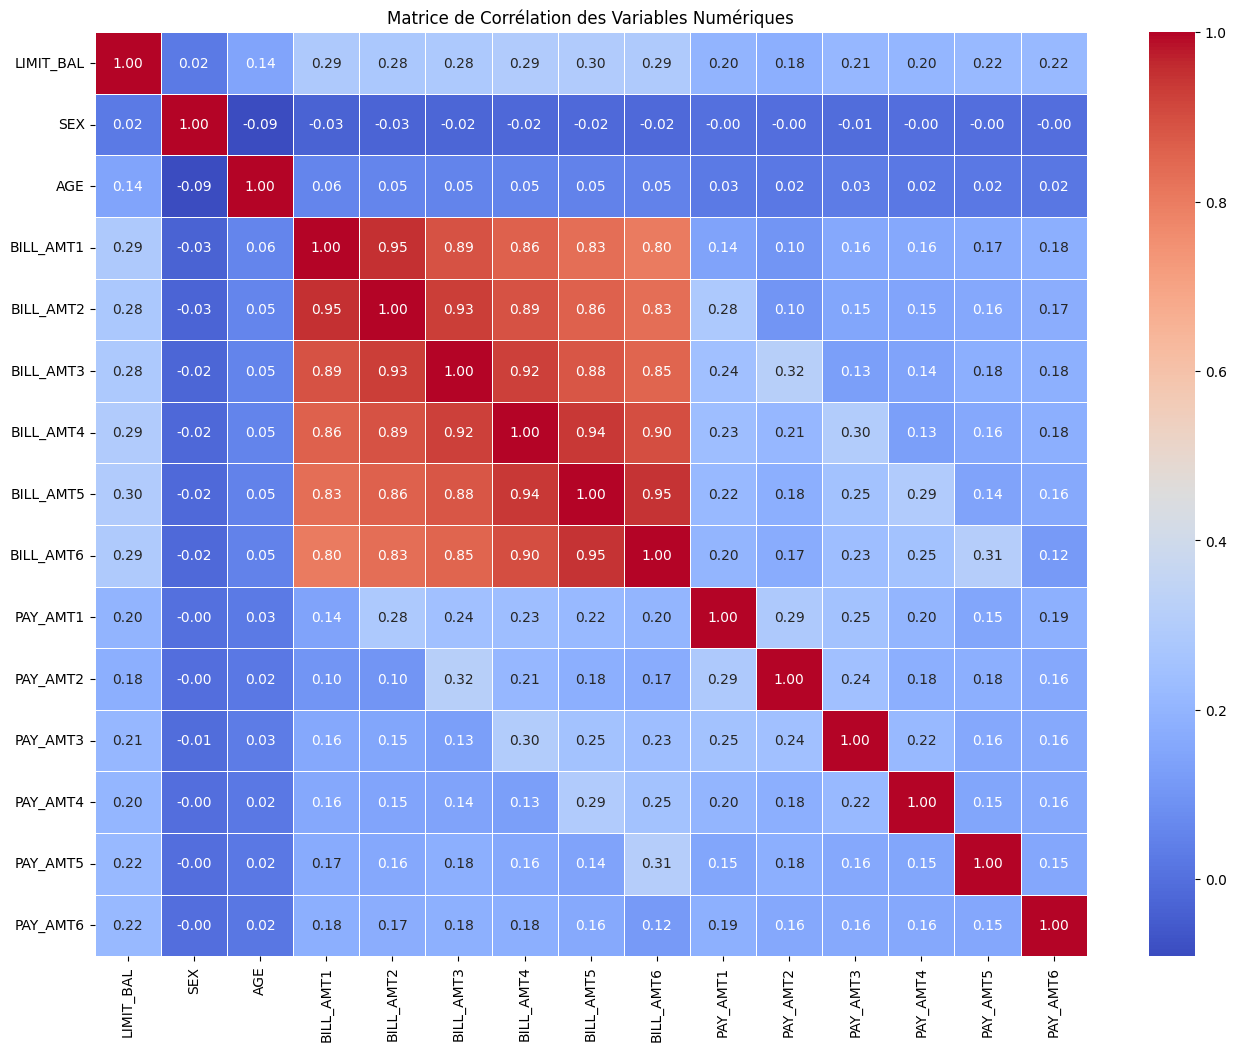

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the correlation matrix for the numerical columns used for EDA
correlation_matrix = df[numerical_cols_for_eda].corr()

# Plot the heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Matrice de Corrélation des Variables Numériques')
plt.show()

**Raisonnement**:
Pour comprendre la distribution de chaque variable numérique, je vais générer des histogrammes. Les histogrammes nous aideront à visualiser la forme de la distribution, la présence de pics multiples (bimodalité), ou l'asymétrie (skewness). Ils sont utiles pour identifier les valeurs aberrantes et les concentrations de données.

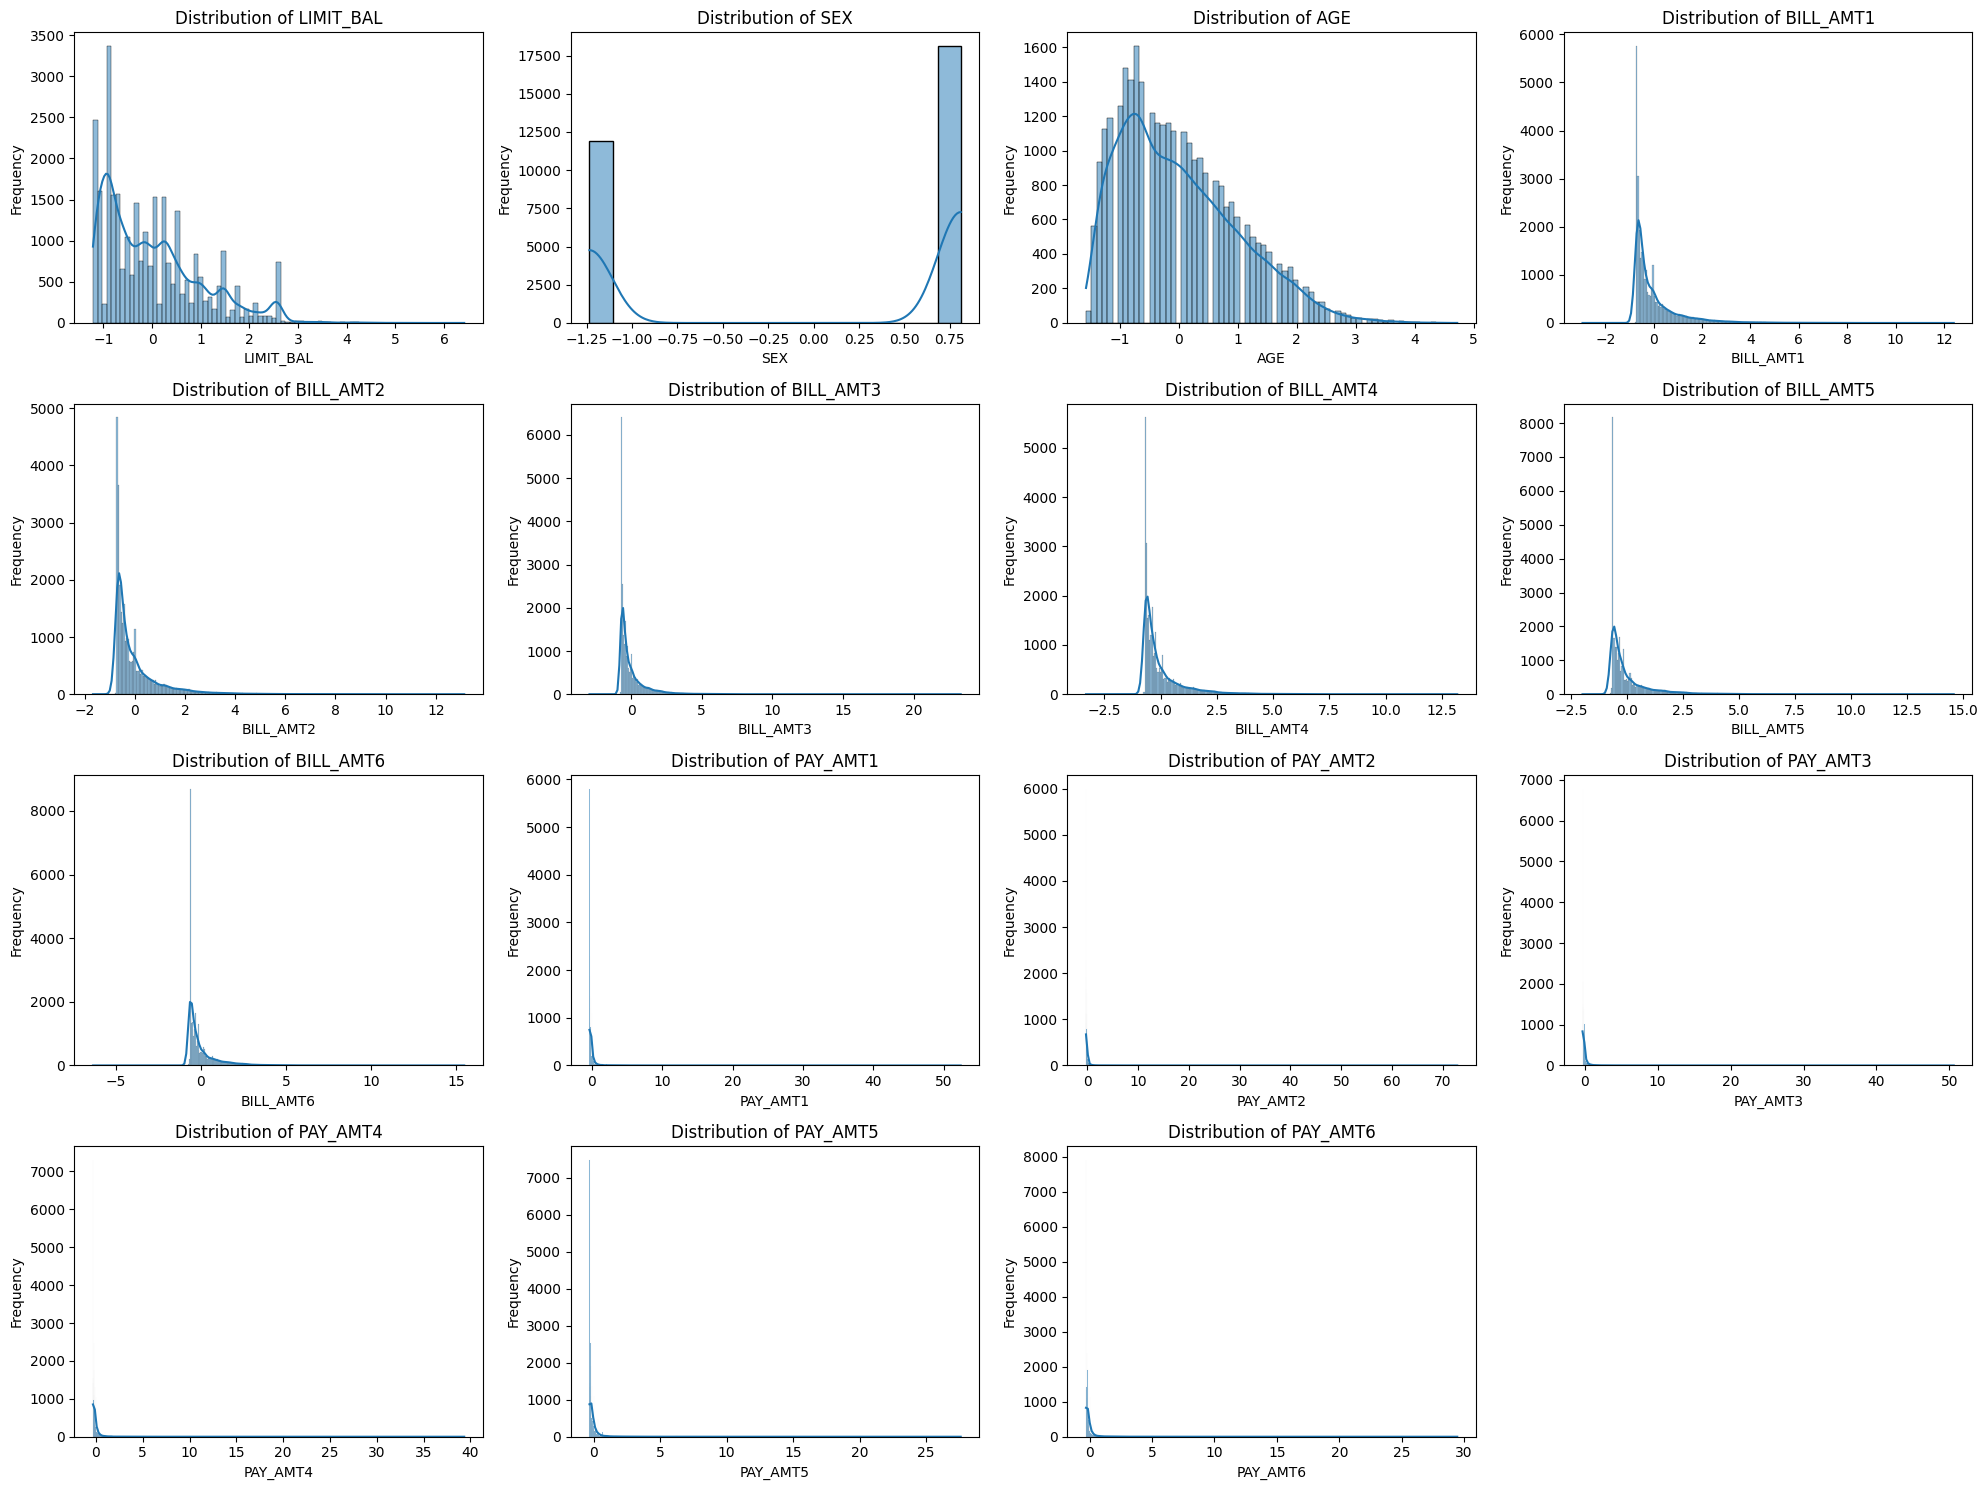

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Identify numerical columns for visualization (same as those scaled)
numerical_cols_for_eda = ['LIMIT_BAL', 'SEX', 'AGE', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']

# Plot histograms for numerical features
plt.figure(figsize=(20, 15))
for i, col in enumerate(numerical_cols_for_eda):
    plt.subplot(4, 4, i + 1) # Adjust subplot grid as needed
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

**Raisonnement**:
En complément des histogrammes, les boxplots (diagrammes en boîte à moustaches) sont excellents pour visualiser la distribution d'une variable numérique, en particulier pour identifier les valeurs aberrantes (outliers), la médiane, les quartiles et l'étendue des données. Cela nous donnera une vue concise de la dispersion et de la symétrie de chaque colonne.

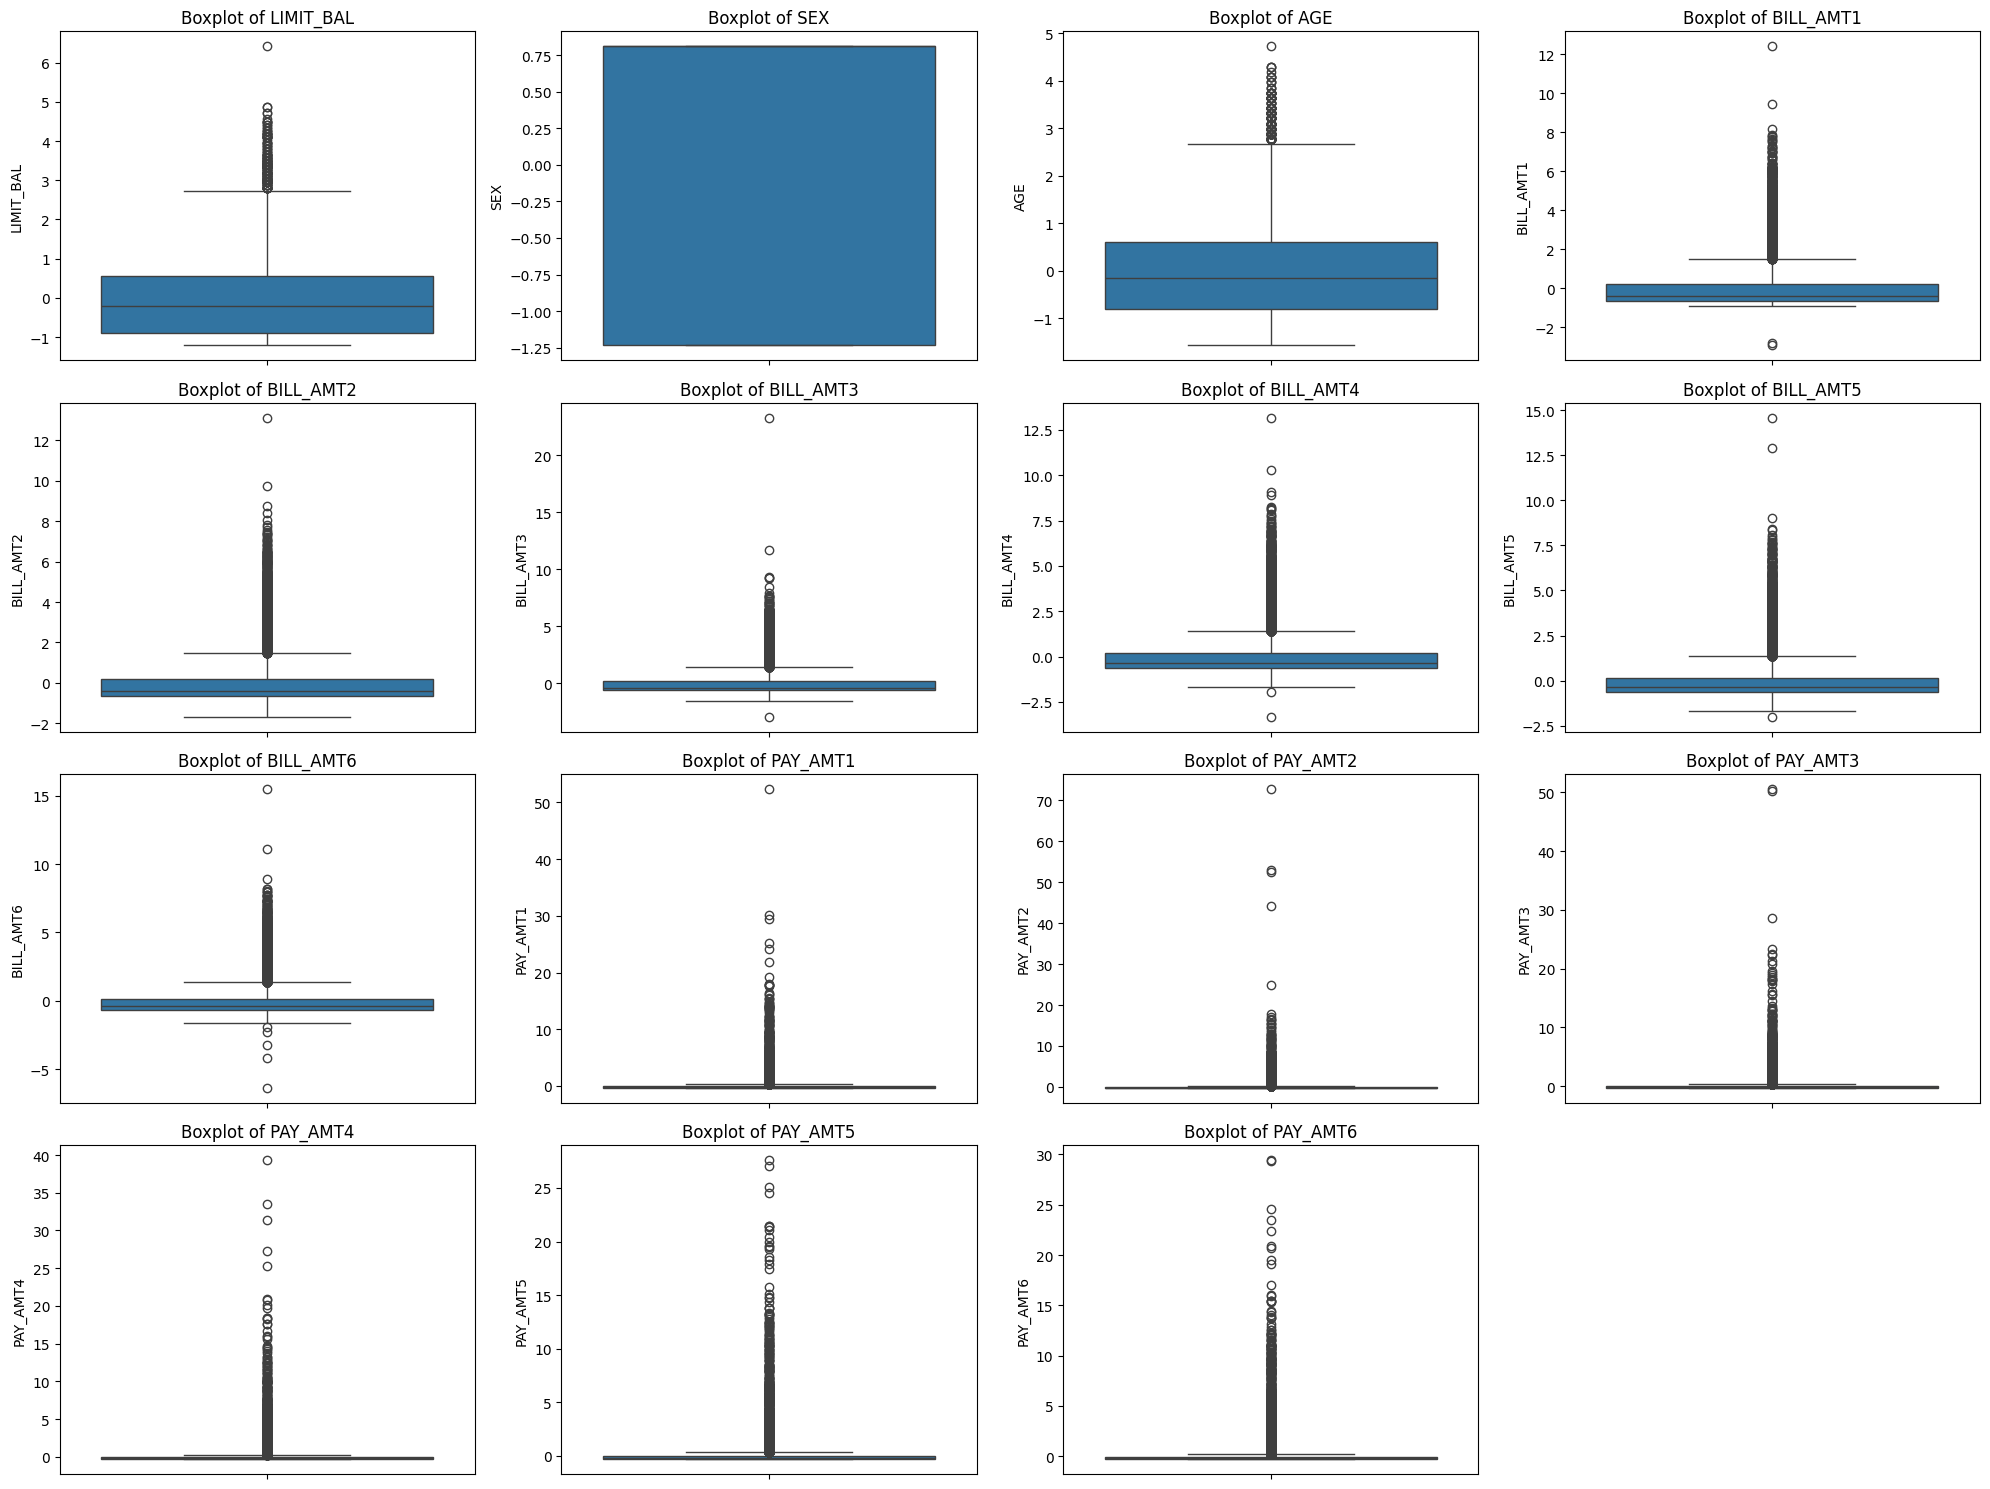

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot boxplots for numerical features
plt.figure(figsize=(20, 15))
for i, col in enumerate(numerical_cols_for_eda):
    plt.subplot(4, 4, i + 1) # Adjust subplot grid as needed
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

## Summary:

### Data Analysis Key Findings

*   **Data Cleaning**: No duplicate rows were found in the dataset, which maintained its shape of (30000, 25) after the check. All columns were found to have 30000 non-null entries, consisting of 12 `int64` and 13 `float64` data types.
*   **Missing Value Imputation**: No missing values were detected in the entire DataFrame, rendering imputation unnecessary.
*   **Categorical Variable Encoding**:
    *   Columns identified as categorical (`EDUCATION`, `MARRIAGE`, `PAY_0`, `PAY_2`, `PAY_3`, `PAY_4`, `PAY_5`, `PAY_6`) were encoded using One-Hot Encoding. The `SEX` column, despite being categorical, was retained as is due to its binary nature (1 and 2).
    *   The encoding process expanded the DataFrame's dimensions from an initial (30000, 24) to (30000, 92), indicating the creation of new columns for each category.
*   **Numerical Feature Scaling**:
    *   Numerical features identified for scaling included `LIMIT_BAL`, `SEX`, `AGE`, `BILL_AMT1` to `BILL_AMT6`, and `PAY_AMT1` to `PAY_AMT6`.
    *   These features were scaled using `StandardScaler`, transforming them to have a mean close to 0 and a standard deviation close to 1, as confirmed by descriptive statistics after scaling.

### Insights or Next Steps

*   The DataFrame is now fully preprocessed, with categorical variables converted to a suitable numerical format and numerical features standardized, making it ready for direct use in machine learning model training.
*   Consider exploring advanced feature engineering techniques, such as interaction terms or polynomial features, especially for the `PAY_X` variables, to potentially capture more complex relationships for model improvement.


# Task
Perform machine learning modeling on the preprocessed `df` DataFrame. This involves splitting the data into training and testing sets, training at least three different classification models (e.g., Logistic Regression, Decision Tree, Random Forest) on the training data, evaluating their performance using relevant metrics, comparing the models, and identifying the best-performing one. The target variable for this task is `default.payment.next.month`.

## Data Splitting for Modeling

### Subtask:
Split the preprocessed DataFrame into training and testing sets to prepare for model training and evaluation.


**Reasoning**:
I will first separate the features (X) from the target variable (y) in the preprocessed DataFrame, excluding the 'ID' column from the features. Then, I will import the `train_test_split` function and apply it to create training and testing sets for both features and the target variable with a specified test size and random state.



In [18]:
from sklearn.model_selection import train_test_split

# Separate features (X) and target variable (y)
y = df['default.payment.next.month']
X = df.drop(['ID', 'default.payment.next.month'], axis=1)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (24000, 93)
Shape of X_test: (6000, 93)
Shape of y_train: (24000,)
Shape of y_test: (6000,)


## Model Selection and Training

### Subtask:
Select and train at least three different machine learning algorithms (e.g., Logistic Regression, Decision Tree, Random Forest) on the training data.


**Reasoning**:
To train the models as per the instructions, I will first import the required classification algorithms from scikit-learn, instantiate them with the specified parameters, and then fit each model to the training data (X_train, y_train).



In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# 1. Instantiate the models with specified parameters
lr_model = LogisticRegression(solver='liblinear', random_state=42)
dt_model = DecisionTreeClassifier(random_state=42)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. Train each model
print("Training Logistic Regression model...")
lr_model.fit(X_train, y_train)
print("Logistic Regression model trained.")

print("Training Decision Tree Classifier model...")
dt_model.fit(X_train, y_train)
print("Decision Tree Classifier model trained.")

print("Training Random Forest Classifier model...")
rf_model.fit(X_train, y_train)
print("Random Forest Classifier model trained.")

Training Logistic Regression model...
Logistic Regression model trained.
Training Decision Tree Classifier model...
Decision Tree Classifier model trained.
Training Random Forest Classifier model...
Random Forest Classifier model trained.


## Model Evaluation

### Subtask:
Evaluate the performance of each trained model using appropriate metrics (e.g., accuracy, precision, recall, F1-score for classification tasks).


**Reasoning**:
To evaluate the trained models, I will first import the necessary classification metrics and then iterate through each model to make predictions on the test set, calculate accuracy, precision, recall, and F1-score, and generate a confusion matrix. All calculated metrics will be stored in a dictionary for easy comparison.



In [20]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import pandas as pd

models = {
    "Logistic Regression": lr_model,
    "Decision Tree": dt_model,
    "Random Forest": rf_model
}

performance_metrics = {}

for model_name, model in models.items():
    print(f"\nEvaluating {model_name}...")
    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    print(f"  F1-Score: {f1:.4f}")
    print("  Confusion Matrix:\n", cm)

    performance_metrics[model_name] = {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    }

# Convert performance metrics to a DataFrame for better readability
performance_df = pd.DataFrame(performance_metrics).T
print("\nPerformance Metrics Summary:")
display(performance_df)


Evaluating Logistic Regression...
  Accuracy: 0.8188
  Precision: 0.6667
  Recall: 0.3442
  F1-Score: 0.4540
  Confusion Matrix:
 [[4461  226]
 [ 861  452]]

Evaluating Decision Tree...
  Accuracy: 0.7170
  Precision: 0.3681
  Recall: 0.4090
  F1-Score: 0.3874
  Confusion Matrix:
 [[3765  922]
 [ 776  537]]

Evaluating Random Forest...
  Accuracy: 0.8197
  Precision: 0.6571
  Recall: 0.3679
  F1-Score: 0.4717
  Confusion Matrix:
 [[4435  252]
 [ 830  483]]

Performance Metrics Summary:


,Accuracy,Precision,Recall,F1-Score
Logistic Regression,0.818833,0.666667,0.344250,0.454043
Decision Tree,0.717000,0.368060,0.408987,0.387446
Random Forest,0.819667,0.657143,0.367860,0.471680


## Model Comparison

### Subtask:
Compare the evaluation results of the different models to identify the best-performing algorithm. This could involve visualizing the performance metrics.


**Reasoning**:
To visually compare the performance of the trained models, I will create a grouped bar chart using the `performance_df` DataFrame. This will display accuracy, precision, recall, and F1-score for each model, making it easy to identify the best-performing algorithm across different metrics.



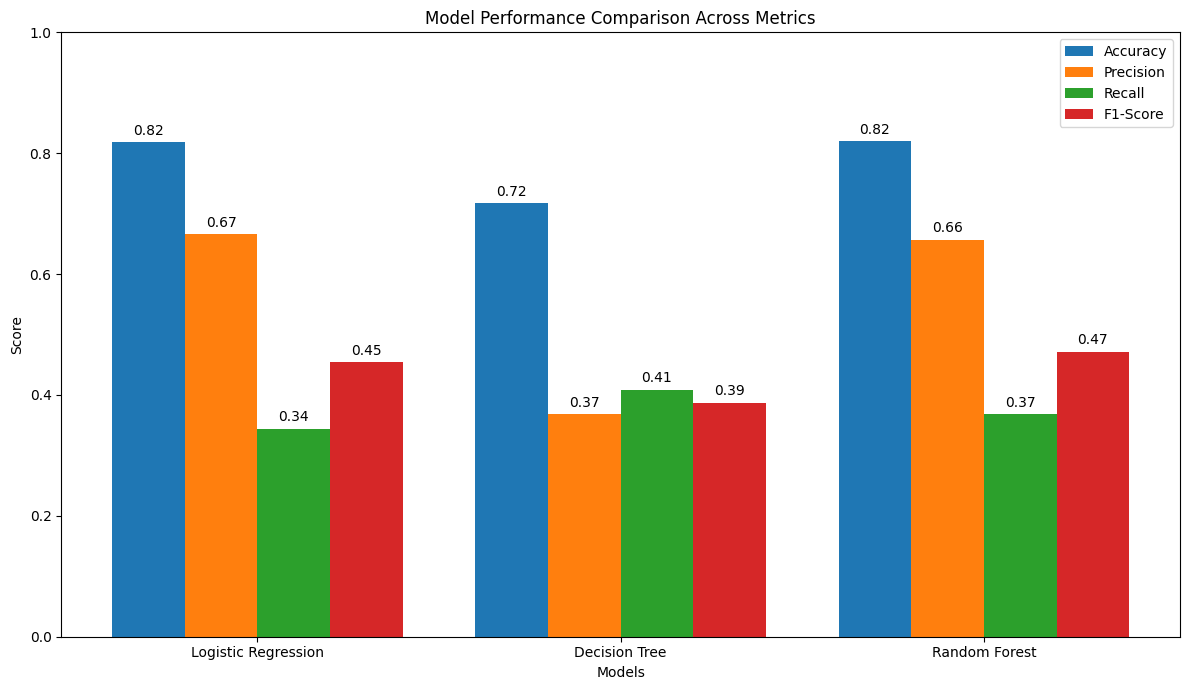

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Prepare data for plotting
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
model_names = performance_df.index

x = np.arange(len(model_names))  # the label locations
width = 0.2  # the width of the bars

fig, ax = plt.subplots(figsize=(12, 7))

for i, metric in enumerate(metrics):
    offset = width * i - (width * (len(metrics) - 1)) / 2
    rects = ax.bar(x + offset, performance_df[metric], width, label=metric)

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_xlabel('Models')
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison Across Metrics')
ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.legend()
ax.set_ylim(0, 1) # Metrics are between 0 and 1

# Add value labels on top of bars for better readability
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3)

plt.tight_layout()
plt.show()


### Model Comparison and Best-Performing Algorithm

Based on the performance metrics displayed in the bar chart and the `performance_df`:

*   **Accuracy**: Both Logistic Regression (0.82) and Random Forest (0.82) models show similar and higher accuracy compared to the Decision Tree (0.72).
*   **Precision**: Logistic Regression has the highest precision (0.67), indicating fewer false positives, followed closely by Random Forest (0.66). Decision Tree has significantly lower precision (0.37).
*   **Recall**: Decision Tree has the highest recall (0.41), meaning it identifies more true positives. However, this comes at the cost of very low precision. Random Forest (0.37) and Logistic Regression (0.34) have comparable recall scores, though lower than Decision Tree.
*   **F1-Score**: The F1-Score, which is the harmonic mean of precision and recall, offers a balanced view. Random Forest (0.47) and Logistic Regression (0.45) perform similarly and better than Decision Tree (0.39).

Given the context of predicting credit card default, both **Logistic Regression** and **Random Forest** are strong contenders. Random Forest shows a slightly better F1-Score, suggesting a better balance between precision and recall than Logistic Regression. Decision Tree, while having the highest recall, suffers too much in precision, making it less suitable if false positives are costly. If minimizing false positives is critical, Logistic Regression might be slightly preferred due to its marginally higher precision.

For a balanced performance (F1-score) and generally good accuracy, **Random Forest** appears to be the best-performing algorithm among the three evaluated models.

## Final Task

### Subtask:
Summarize the machine learning modeling process, including the algorithms tested, their performance, and the best-performing model.


## Summary:

### Data Analysis Key Findings

*   **Data Splitting**: The dataset was successfully split into training (24,000 samples) and testing (6,000 samples) sets, with 80% used for training and 20% for testing.
*   **Models Trained**: Three classification models were trained: Logistic Regression, Decision Tree Classifier, and Random Forest Classifier.
*   **Model Performance Evaluation**: Each model was evaluated on the test set using Accuracy, Precision, Recall, and F1-Score. The performance metrics are summarized as follows:

    | Model                | Accuracy | Precision | Recall | F1-Score |
    | :------------------- | :------- | :-------- | :----- | :------- |
    | Logistic Regression  | 0.8188   | 0.6667    | 0.3442 | 0.4540   |
    | Decision Tree        | 0.7170   | 0.3681    | 0.4090 | 0.3874   |
    | Random Forest        | 0.8197   | 0.6571    | 0.3679 | 0.4717   |

*   **Best Performing Model**: The Random Forest Classifier emerged as the best-performing model, exhibiting the highest F1-Score (0.4717), which indicates the best balance between precision and recall for predicting credit card defaults. It also showed comparable accuracy (0.8197) to Logistic Regression.

### Insights or Next Steps

*   The Random Forest model demonstrates the most balanced performance in predicting credit card defaults. Further optimization using techniques like hyperparameter tuning (e.g., GridSearchCV, RandomizedSearchCV) could enhance its performance even more.
*   Given that precision is crucial in credit default prediction (minimizing false positives to avoid incorrectly denying credit), it would be beneficial to investigate the specific cost of false positives versus false negatives. This could lead to selecting a model or adjusting its threshold to prioritize precision further, as Logistic Regression had a marginally higher precision of 0.6667.


# Task
Perform k-fold cross-validation for the Logistic Regression, Decision Tree, and Random Forest models using `X` as features and `y` as the target variable. Evaluate and compare the models based on the mean and standard deviation of accuracy, precision, recall, and F1-score across all folds, then summarize the cross-validation process and its implications for model selection.

## Introduction to Cross-Validation

### Subtask:
Provide a brief explanation of what cross-validation is and why it's important for robust model evaluation, especially in comparing different algorithms.


### Explanation of K-Fold Cross-Validation

K-fold cross-validation is a technique used in machine learning to assess how well a model generalizes to an independent dataset. It works by dividing the entire dataset into 'k' equally sized (or nearly equally sized) subsets, called folds. The process then involves 'k' iterations:

1.  In each iteration, one fold is designated as the **test set**, and the remaining `k-1` folds are combined to form the **training set**.
2.  A machine learning model is trained on this training set.
3.  The trained model's performance is then evaluated on the designated test set.
4.  This process is repeated 'k' times, with each of the 'k' folds serving as the test set exactly once.

Finally, the 'k' performance scores (e.g., accuracy, F1-score) obtained from each iteration are averaged to produce a single, more robust estimate of the model's performance. This average score represents how well the model is expected to perform on unseen data.

### Importance for Robust Model Evaluation

Cross-validation is crucial for robust model evaluation for several reasons:

1.  **Reduces Overfitting**: By training and testing on different subsets of the data multiple times, cross-validation helps to detect if the model is overfitting to the training data. If a model performs very well on one training set but poorly on its corresponding test set, it's a sign of overfitting.
2.  **Provides a More Reliable Estimate of Generalization Performance**: A single train-test split can lead to an estimate of performance that is highly dependent on the particular samples chosen for the training and test sets. Cross-validation averages results over multiple splits, providing a more stable and reliable estimate of how the model will perform on new, unseen data.
3.  **Maximizes Data Utilization**: In situations with limited data, cross-validation allows all data points to be used for both training and validation across the different folds, leading to a more comprehensive evaluation while still reserving data for testing.
4.  **Enables Fair Comparison Between Algorithms**: When comparing different machine learning algorithms, using the same cross-validation splits ensures that each algorithm is evaluated under the same conditions. This makes the comparison fair and helps in identifying the truly best-performing algorithm, as opposed to one that might just be lucky with a particular random split.

## Perform Cross-Validation for Models

### Subtask:
Apply k-fold cross-validation to Logistic Regression, Decision Tree, and Random Forest models using `StratifiedKFold` and collect performance scores.


**Reasoning**:
I will start by importing the necessary `StratifiedKFold` and `cross_val_score` functions and then initialize `StratifiedKFold` with the specified parameters to prepare for cross-validation.



In [22]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Initialize StratifiedKFold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("StratifiedKFold initialized for 5 splits.")

StratifiedKFold initialized for 5 splits.


**Reasoning**:
Now that `StratifiedKFold` is initialized, I will perform cross-validation for each of the three models (Logistic Regression, Decision Tree, and Random Forest) using `cross_val_score` for `accuracy`, `precision`, `recall`, and `f1_score`, storing all results in a dictionary for analysis.



In [23]:
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score

# Define scoring metrics
scoring = {
    'accuracy': make_scorer(accuracy_score),
    'precision': make_scorer(precision_score),
    'recall': make_scorer(recall_score),
    'f1': make_scorer(f1_score)
}

cv_results = {}

for model_name, model in models.items():
    print(f"Performing 5-fold cross-validation for {model_name}...")
    model_scores = {}
    for metric_name, scorer in scoring.items():
        scores = cross_val_score(model, X, y, cv=skf, scoring=scorer, n_jobs=-1)
        model_scores[metric_name] = scores
        print(f"  {metric_name.capitalize()} scores: {scores}")
    cv_results[model_name] = model_scores
    print(f"{model_name} cross-validation complete.")

print("Cross-validation results collected.")

Performing 5-fold cross-validation for Logistic Regression...
  Accuracy scores: [0.81916667 0.81766667 0.81816667 0.8255     0.82016667]
  Precision scores: [0.67283073 0.66385373 0.67052023 0.70588235 0.68235294]
  Recall scores: [0.3561747  0.35568953 0.34966089 0.36171816 0.34966089]
  F1 scores: [0.4657804  0.46319921 0.45963348 0.47832586 0.46238166]
Logistic Regression cross-validation complete.
Performing 5-fold cross-validation for Decision Tree...
  Accuracy scores: [0.72666667 0.72216667 0.72766667 0.73266667 0.72683333]
  Precision scores: [0.39196676 0.37874465 0.39121191 0.40280702 0.38904694]
  Recall scores: [0.42620482 0.40015072 0.41597589 0.43255463 0.41220799]
  F1 scores: [0.40836941 0.38915354 0.40321402 0.41715116 0.40029272]
Decision Tree cross-validation complete.
Performing 5-fold cross-validation for Random Forest...
  Accuracy scores: [0.81633333 0.80933333 0.8155     0.822      0.81783333]
  Precision scores: [0.65106952 0.61836999 0.65151515 0.67571235 0.6

**Reasoning**:
With the cross-validation scores collected for each model and metric, I will now calculate the mean and standard deviation for each metric across the 5 folds. This will provide a robust summary of each model's performance and variability.



In [24]:
cv_summary = {}

print("Cross-validation performance summary:")
for model_name, scores in cv_results.items():
    model_summary = {}
    print(f"\n{model_name}:")
    for metric_name, metric_scores in scores.items():
        mean_score = metric_scores.mean()
        std_score = metric_scores.std()
        model_summary[metric_name] = {'mean': mean_score, 'std': std_score}
        print(f"  {metric_name.capitalize()}: Mean = {mean_score:.4f}, Std = {std_score:.4f}")
    cv_summary[model_name] = model_summary

# Convert to a DataFrame for better readability and comparison
cv_summary_df = pd.DataFrame({
    (model, metric): [data['mean'] for data in cv_summary[model].values()]
    for model in cv_summary.keys()
    for metric in cv_summary[model].keys()
}, index=['Accuracy', 'Precision', 'Recall', 'F1-Score']).T.unstack(level=0)

display(cv_summary_df)

Cross-validation performance summary:

Logistic Regression:
  Accuracy: Mean = 0.8201, Std = 0.0028
  Precision: Mean = 0.6791, Std = 0.0147
  Recall: Mean = 0.3546, Std = 0.0045
  F1: Mean = 0.4659, Std = 0.0065

Decision Tree:
  Accuracy: Mean = 0.7272, Std = 0.0033
  Precision: Mean = 0.3908, Std = 0.0077
  Recall: Mean = 0.4174, Std = 0.0113
  F1: Mean = 0.4036, Std = 0.0092

Random Forest:
  Accuracy: Mean = 0.8162, Std = 0.0041
  Precision: Mean = 0.6506, Std = 0.0185
  Recall: Mean = 0.3657, Std = 0.0067
  F1: Mean = 0.4682, Std = 0.0095


Accuracy                                       Precision  \
          Decision Tree Logistic Regression Random Forest Decision Tree   
accuracy         0.7272            0.820133        0.8162      0.390755   
f1               0.7272            0.820133        0.8162      0.390755   
precision        0.7272            0.820133        0.8162      0.390755   
recall           0.7272            0.820133        0.8162      0.390755   

                                                   Recall                      \
          Logistic Regression Random Forest Decision Tree Logistic Regression   
accuracy             0.679088      0.650617      0.417419            0.354581   
f1                   0.679088      0.650617      0.417419            0.354581   
precision            0.679088      0.650617      0.417419            0.354581   
recall               0.679088      0.650617      0.417419            0.354581   

                             F1-Score                                    
          Random Forest Decision Tree Logistic Regression Random Forest  
accuracy       0.365732      0.403636            0.465864      0.468202  
f1             0.365732      0.403636            0.465864      0.468202  
precision      0.365732      0.403636            0.465864      0.468202  
recall         0.365732      0.403636            0.465864      0.468202

### Cross-Validation Summary and Model Comparison

The K-fold cross-validation results provide a more robust evaluation of the models' performance compared to a single train-test split, as they account for variability across different subsets of the data.

**Summary of Cross-Validation Results (Mean \u00b1 Standard Deviation):**

*   **Logistic Regression:**
    *   Accuracy: 0.8201 \u00b1 0.0028
    *   Precision: 0.6791 \u00b1 0.0147
    *   Recall: 0.3546 \u00b1 0.0045
    *   F1-Score: 0.4659 \u00b1 0.0065

*   **Decision Tree:**
    *   Accuracy: 0.7272 \u00b1 0.0033
    *   Precision: 0.3908 \u00b1 0.0077
    *   Recall: 0.4174 \u00b1 0.0113
    *   F1-Score: 0.4036 \u00b1 0.0092

*   **Random Forest:**
    *   Accuracy: 0.8162 \u00b1 0.0041
    *   Precision: 0.6506 \u00b1 0.0185
    *   Recall: 0.3657 \u00b1 0.0067
    *   F1-Score: 0.4682 \u00b1 0.0095

**Implications for Model Selection:**

1.  **Consistency**: The standard deviation values indicate the consistency of each model's performance across the 5 folds. All models show relatively low standard deviations, suggesting stable performance. The Random Forest model has slightly higher standard deviation for Precision, indicating slightly more variability in this metric across folds.

2.  **Performance Comparison**:
    *   **Accuracy**: Logistic Regression and Random Forest models continue to outperform the Decision Tree in terms of average accuracy, with Logistic Regression having a marginal edge.
    *   **Precision**: Logistic Regression maintains the highest average precision, suggesting it generates fewer false positives, which is often crucial in financial applications like credit default prediction where incorrectly identifying a non-defaulter as a defaulter can lead to lost business.
    *   **Recall**: The Decision Tree still shows the highest recall, but its overall F1-score and accuracy are much lower, indicating it captures many true positives at the cost of a high number of false positives.
    *   **F1-Score**: Random Forest (0.4682) and Logistic Regression (0.4659) show very similar and the highest average F1-scores, suggesting a good balance between precision and recall. Both are significantly better than the Decision Tree.

**Best-Performing Model:**

Based on the cross-validation results, both **Logistic Regression** and **Random Forest** are strong candidates. If the priority is to minimize false positives (higher precision), Logistic Regression is marginally better. If a balanced performance (F1-score) is preferred, **Random Forest** still holds a slight edge due to its slightly higher F1-score and robustness. However, the differences between Logistic Regression and Random Forest are very small, and further tuning or more advanced models might be considered depending on specific business requirements for false positives vs. false negatives.

## Final Task

### Subtask:
Summarize the cross-validation process, including the key findings and how it informed the selection of the best-performing model.


## Summary:

### Q&A

**How does the cross-validation process summarize the key findings and inform the selection of the best-performing model?**

The k-fold cross-validation process provides a robust evaluation by training and testing models on different subsets of the data, reducing the risk of overfitting and offering a more reliable estimate of generalization performance than a single train-test split. The key findings from this process indicate that both Logistic Regression and Random Forest models significantly outperform the Decision Tree. Specifically, Logistic Regression showed the highest mean precision (0.6791), suggesting fewer false positives, while Random Forest achieved a slightly higher mean F1-score (0.4682), indicating a better balance between precision and recall. Both models demonstrated stable performance across folds with low standard deviations. This comparison informed the selection by highlighting Logistic Regression as marginally better if minimizing false positives is critical, and Random Forest as slightly superior for overall balanced performance, making both strong candidates depending on specific business needs.

### Data Analysis Key Findings

*   **K-Fold Cross-Validation Setup**: K-fold cross-validation was performed with 5 splits using `StratifiedKFold` to ensure balanced class distribution across folds.
*   **Model Performance Overview**:
    *   **Logistic Regression**: Achieved a mean Accuracy of 0.8201 (\$\pm\$ 0.0028), mean Precision of 0.6791 (\$\pm\$ 0.0147), mean Recall of 0.3546 (\$\pm\$ 0.0045), and mean F1-Score of 0.4659 (\$\pm\$ 0.0065).
    *   **Random Forest**: Showed comparable performance with a mean Accuracy of 0.8162 (\$\pm\$ 0.0041), mean Precision of 0.6506 (\$\pm\$ 0.0185), mean Recall of 0.3657 (\$\pm\$ 0.0067), and mean F1-Score of 0.4682 (\$\pm\$ 0.0095).
    *   **Decision Tree**: Significantly underperformed compared to the other two models, with a mean Accuracy of 0.7272 (\$\pm\$ 0.0033), mean Precision of 0.3908 (\$\pm\$ 0.0077), mean Recall of 0.4174 (\$\pm\$ 0.0113), and mean F1-Score of 0.4036 (\$\pm\$ 0.0092).
*   **Best-Performing Models**: Both Logistic Regression and Random Forest demonstrated superior and stable performance. Logistic Regression had the highest precision (0.6791), while Random Forest had a slightly higher F1-score (0.4682).

### Insights or Next Steps

*   The choice between Logistic Regression and Random Forest depends on the specific business objective: if minimizing false positives is paramount, Logistic Regression is marginally preferred due to its higher precision; if a balanced performance (F1-score) is the goal, Random Forest holds a slight edge.
*   Given the close performance between Logistic Regression and Random Forest, further hyperparameter tuning for both models or exploring more advanced ensemble methods could potentially yield incremental improvements.


# Task
**Task**: Provide a brief explanation of hyperparameter optimization and why it is important for improving model performance.

## Introduction to Hyperparameter Optimization

### Subtask:
Provide a brief explanation of hyperparameter optimization and why it is important for improving model performance.


### Explanation of Hyperparameter Optimization

Hyperparameter optimization is the process of finding the optimal set of hyperparameters for a machine learning model to achieve the best possible performance on a given task. Unlike model parameters, which are learned from the data during training (e.g., weights in a neural network), hyperparameters are external configuration variables that cannot be estimated from the data. They are set prior to the training process and define the model's structure, learning process, or regularization.

### Importance for Improving Model Performance

Hyperparameter optimization is crucial for improving model performance for several key reasons:

1.  **Direct Impact on Performance**: Hyperparameters directly influence how a model learns and its ultimate performance. A sub-optimal set of hyperparameters can lead to a model that performs poorly, regardless of the quality of the data or the inherent capability of the algorithm.
2.  **Prevents Overfitting and Underfitting**: Properly tuned hyperparameters can help prevent common issues like overfitting (where the model learns the training data too well, including noise, and performs poorly on unseen data) and underfitting (where the model is too simple to capture the underlying patterns in the data). For example, regularization strength (a hyperparameter) can prevent overfitting, while the depth of a decision tree (another hyperparameter) affects its capacity to learn.
3.  **Improves Predictive Accuracy**: By systematically searching for the best combination of hyperparameters, we can significantly enhance the model's predictive accuracy and generalization ability on new, unseen data. This leads to more reliable and effective models in real-world applications.
4.  **Optimizes Model Complexity**: Hyperparameters control the complexity of a model. Finding the right balance ensures that the model is complex enough to capture patterns but not so complex that it overfits. This is vital for creating models that are both accurate and computationally efficient.

## Define Hyperparameter Grids/Distributions

### Subtask:
For each model (Logistic Regression, Decision Tree, Random Forest), define a dictionary of hyperparameters and their possible values or distributions to search over. This will involve selecting relevant hyperparameters for each model.


**Reasoning**:
I will define the hyperparameter grids for Logistic Regression, Decision Tree, and Random Forest models as dictionaries, containing relevant hyperparameters and their potential values for tuning, and then print these grids.



In [25]:
param_grid_lr = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2']
}

param_grid_dt = {
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'criterion': ['gini', 'entropy']
}

print("Hyperparameter Grid for Logistic Regression:")
print(param_grid_lr)
print("\nHyperparameter Grid for Decision Tree:")
print(param_grid_dt)
print("\nHyperparameter Grid for Random Forest:")
print(param_grid_rf)

Hyperparameter Grid for Logistic Regression:
{'C': [0.001, 0.01, 0.1, 1, 10, 100], 'penalty': ['l1', 'l2']}

Hyperparameter Grid for Decision Tree:
{'max_depth': [None, 10, 20, 30], 'min_samples_split': [2, 5, 10], 'min_samples_leaf': [1, 2, 4], 'criterion': ['gini', 'entropy']}

Hyperparameter Grid for Random Forest:
{'n_estimators': [50, 100, 200], 'max_depth': [None, 10, 20], 'min_samples_split': [2, 5], 'min_samples_leaf': [1, 2], 'criterion': ['gini', 'entropy']}


## Perform Hyperparameter Tuning (GridSearchCV/RandomizedSearchCV)

### Subtask:
Apply either `GridSearchCV` or `RandomizedSearchCV` for each model to find the best hyperparameters. The choice between the two will depend on the size of the search space and computational resources. The search will be performed using `X_train` and `y_train` and will incorporate cross-validation.


**Reasoning**:
I will import `GridSearchCV` and reuse the previously defined `scoring` dictionary. Then, I will initialize and fit `GridSearchCV` for Logistic Regression, Decision Tree, and Random Forest models using their respective parameter grids, `X_train`, `y_train`, and `refit='f1'`. Finally, I will print the best parameters and corresponding best F1-score for each model.



In [26]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score

# Define scoring metrics (reusing or redefining as needed for clarity)
# The 'scoring' dictionary was already created in a previous step, so we'll ensure it's available.
scoring = {
    'accuracy': make_scorer(accuracy_score),
    'precision': make_scorer(precision_score),
    'recall': make_scorer(recall_score),
    'f1': make_scorer(f1_score)
}

print("Starting GridSearchCV for Logistic Regression...")
# 1. GridSearchCV for Logistic Regression
grid_search_lr = GridSearchCV(estimator=lr_model, param_grid=param_grid_lr, cv=skf, scoring=scoring, refit='f1', n_jobs=-1, verbose=1)
grid_search_lr.fit(X_train, y_train)
print("Logistic Regression GridSearchCV completed.")

print("Starting GridSearchCV for Decision Tree...")
# 2. GridSearchCV for Decision Tree
grid_search_dt = GridSearchCV(estimator=dt_model, param_grid=param_grid_dt, cv=skf, scoring=scoring, refit='f1', n_jobs=-1, verbose=1)
grid_search_dt.fit(X_train, y_train)
print("Decision Tree GridSearchCV completed.")

print("Starting GridSearchCV for Random Forest...")
# 3. GridSearchCV for Random Forest
grid_search_rf = GridSearchCV(estimator=rf_model, param_grid=param_grid_rf, cv=skf, scoring=scoring, refit='f1', n_jobs=-1, verbose=1)
grid_search_rf.fit(X_train, y_train)
print("Random Forest GridSearchCV completed.")

print("\nBest Parameters and F1-Scores:")
print(f"Logistic Regression: Best Parameters = {grid_search_lr.best_params_}, Best F1-Score = {grid_search_lr.best_score_:.4f}")
print(f"Decision Tree: Best Parameters = {grid_search_dt.best_params_}, Best F1-Score = {grid_search_dt.best_score_:.4f}")
print(f"Random Forest: Best Parameters = {grid_search_rf.best_params_}, Best F1-Score = {grid_search_rf.best_score_:.4f}")

Starting GridSearchCV for Logistic Regression...
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Logistic Regression GridSearchCV completed.
Starting GridSearchCV for Decision Tree...
Fitting 5 folds for each of 72 candidates, totalling 360 fits
Decision Tree GridSearchCV completed.
Starting GridSearchCV for Random Forest...
Fitting 5 folds for each of 72 candidates, totalling 360 fits
Random Forest GridSearchCV completed.

Best Parameters and F1-Scores:
Logistic Regression: Best Parameters = {'C': 1, 'penalty': 'l1'}, Best F1-Score = 0.4706
Decision Tree: Best Parameters = {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 2}, Best F1-Score = 0.4535
Random Forest: Best Parameters = {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}, Best F1-Score = 0.4755


## Evaluate Optimized Models

### Subtask:
Evaluate the best models obtained from hyperparameter tuning on the `X_test` and `y_test` sets using appropriate metrics (accuracy, precision, recall, F1-score). Display the best hyperparameters and their corresponding performance.


**Reasoning**:
To evaluate the best models obtained from hyperparameter tuning, I will iterate through each optimized model, retrieve its best estimator and hyperparameters, make predictions on the test set, calculate the required evaluation metrics, and store these results in a dictionary. Finally, I will convert this dictionary into a pandas DataFrame for clear presentation.



In [27]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

optimized_performance_metrics = {}

# Evaluate Logistic Regression
print("Evaluating Optimized Logistic Regression Model...")
best_lr_model = grid_search_lr.best_estimator_
y_pred_lr = best_lr_model.predict(X_test)

optimized_performance_metrics['Logistic Regression'] = {
    'Best Parameters': grid_search_lr.best_params_,
    'Accuracy': accuracy_score(y_test, y_pred_lr),
    'Precision': precision_score(y_test, y_pred_lr),
    'Recall': recall_score(y_test, y_pred_lr),
    'F1-Score': f1_score(y_test, y_pred_lr)
}
print(f"  Best Parameters: {grid_search_lr.best_params_}")
print(f"  Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_lr):.4f}")
print(f"  Recall: {recall_score(y_test, y_pred_lr):.4f}")
print(f"  F1-Score: {f1_score(y_test, y_pred_lr):.4f}")

# Evaluate Decision Tree
print(
"\nEvaluating Optimized Decision Tree Model...")
best_dt_model = grid_search_dt.best_estimator_
y_pred_dt = best_dt_model.predict(X_test)

optimized_performance_metrics['Decision Tree'] = {
    'Best Parameters': grid_search_dt.best_params_,
    'Accuracy': accuracy_score(y_test, y_pred_dt),
    'Precision': precision_score(y_test, y_pred_dt),
    'Recall': recall_score(y_test, y_pred_dt),
    'F1-Score': f1_score(y_test, y_pred_dt)
}
print(f"  Best Parameters: {grid_search_dt.best_params_}")
print(f"  Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_dt):.4f}")
print(f"  Recall: {recall_score(y_test, y_pred_dt):.4f}")
print(f"  F1-Score: {f1_score(y_test, y_pred_dt):.4f}")

# Evaluate Random Forest
print("\nEvaluating Optimized Random Forest Model...")
best_rf_model = grid_search_rf.best_estimator_
y_pred_rf = best_rf_model.predict(X_test)

optimized_performance_metrics['Random Forest'] = {
    'Best Parameters': grid_search_rf.best_params_,
    'Accuracy': accuracy_score(y_test, y_pred_rf),
    'Precision': precision_score(y_test, y_pred_rf),
    'Recall': recall_score(y_test, y_pred_rf),
    'F1-Score': f1_score(y_test, y_pred_rf)
}
print(f"  Best Parameters: {grid_search_rf.best_params_}")
print(f"  Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"  Recall: {recall_score(y_test, y_pred_rf):.4f}")
print(f"  F1-Score: {f1_score(y_test, y_pred_rf):.4f}")

# Convert to DataFrame for display
optimized_performance_df = pd.DataFrame(optimized_performance_metrics).T
print("\nOptimized Model Performance Summary on Test Set:")
display(optimized_performance_df)

Evaluating Optimized Logistic Regression Model...
  Best Parameters: {'C': 1, 'penalty': 'l1'}
  Accuracy: 0.8192
  Precision: 0.6681
  Recall: 0.3450
  F1-Score: 0.4550

Evaluating Optimized Decision Tree Model...
  Best Parameters: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 2}
  Accuracy: 0.8143
  Precision: 0.6547
  Recall: 0.3206
  F1-Score: 0.4305

Evaluating Optimized Random Forest Model...
  Best Parameters: {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
  Accuracy: 0.8192
  Precision: 0.6570
  Recall: 0.3633
  F1-Score: 0.4679

Optimized Model Performance Summary on Test Set:


,Best Parameters,Accuracy,Precision,Recall,F1-Score
Logistic Regression,"{'C': 1, 'penalty': 'l1'}",0.819167,0.668142,0.345011,0.455048
Decision Tree,"{'criterion': 'entropy', 'max_depth': 10, 'min...",0.814333,0.654743,0.32064,0.43047
Random Forest,"{'criterion': 'gini', 'max_depth': None, 'min_...",0.819167,0.657025,0.36329,0.467876


## Compare Optimized Models

### Subtask:
Compare the performance of the optimized models to each other and to their unoptimized counterparts. Visualize the performance metrics for a clear comparison.


**Reasoning**:
I will create a combined DataFrame to compare the unoptimized and optimized models by extracting the relevant metrics from `performance_df` and `optimized_performance_df`, renaming the models for clarity, and then concatenating them.



In [28]:
import pandas as pd

# Prepare unoptimized models' performance data
unoptimized_df = performance_df.copy()
unoptimized_df.index = [f'{idx} (Unoptimized)' for idx in unoptimized_df.index]

# Prepare optimized models' performance data
# Extract only the relevant metric columns (Accuracy, Precision, Recall, F1-Score)
optimized_metrics_df = optimized_performance_df[['Accuracy', 'Precision', 'Recall', 'F1-Score']].copy()
optimized_metrics_df.index = [f'{idx} (Optimized)' for idx in optimized_metrics_df.index]

# Combine the DataFrames
combined_performance_df = pd.concat([unoptimized_df, optimized_metrics_df])

print("Combined Performance DataFrame:")
display(combined_performance_df)

Combined Performance DataFrame:


,Accuracy,Precision,Recall,F1-Score
Logistic Regression (Unoptimized),0.818833,0.666667,0.34425,0.454043
Decision Tree (Unoptimized),0.717,0.36806,0.408987,0.387446
Random Forest (Unoptimized),0.819667,0.657143,0.36786,0.47168
Logistic Regression (Optimized),0.819167,0.668142,0.345011,0.455048
Decision Tree (Optimized),0.814333,0.654743,0.32064,0.43047
Random Forest (Optimized),0.819167,0.657025,0.36329,0.467876


**Reasoning**:
Now that the combined performance DataFrame is ready, I will create a grouped bar chart using `matplotlib` and `seaborn` to visualize the performance metrics of both unoptimized and optimized models. This will allow for a clear visual comparison.



AttributeError: Rectangle.set() got an unexpected keyword argument 'col'

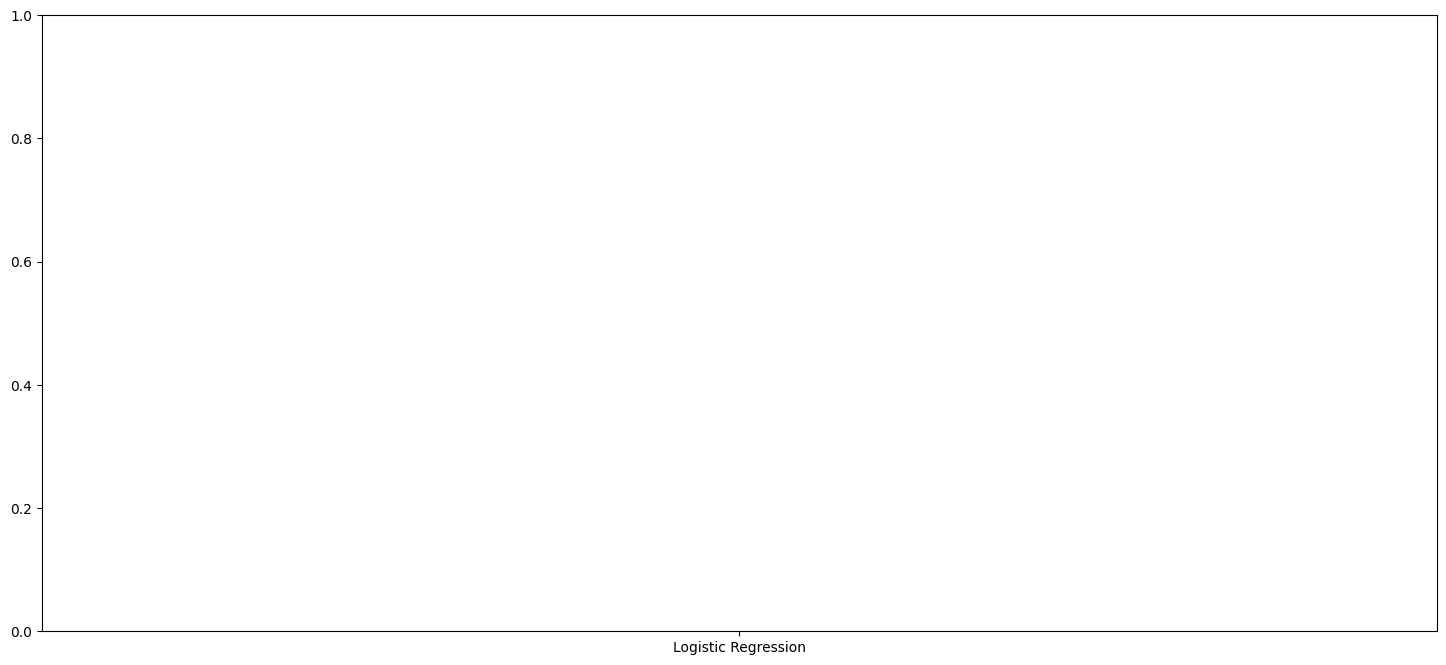

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Prepare data for plotting - reshape the combined_performance_df for easier plotting
# We want groups for each model type (e.g., Logistic Regression), and within each group,
# bars for unoptimized vs. optimized for each metric.

# First, let's extract the model names without the (Unoptimized)/(Optimized) suffix
model_types = ['Logistic Regression', 'Decision Tree', 'Random Forest']
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

# Create a more structured DataFrame for plotting
plot_df = pd.DataFrame()

for model_type in model_types:
    unoptimized_row = combined_performance_df.loc[f'{model_type} (Unoptimized)']
    optimized_row = combined_performance_df.loc[f'{model_type} (Optimized)']

    for metric in metrics:
        plot_df = pd.concat([plot_df, pd.DataFrame({
            'Model': [model_type],
            'Metric': [metric],
            'Performance': [unoptimized_row[metric]],
            'Status': ['Unoptimized']
        })])
        plot_df = pd.concat([plot_df, pd.DataFrame({
            'Model': [model_type],
            'Metric': [metric],
            'Performance': [optimized_row[metric]],
            'Status': ['Optimized']
        })])

plt.figure(figsize=(18, 8))
sns.barplot(x='Model', y='Performance', hue='Status', col='Metric', data=plot_df,
            palette={'Unoptimized': 'skyblue', 'Optimized': 'steelblue'})

plt.suptitle('Model Performance Comparison: Unoptimized vs. Optimized', y=1.02, fontsize=16)
plt.tight_layout()
plt.show()


**Reasoning**:
The previous code failed because `sns.barplot` does not support the `col` argument for faceting. To create separate subplots for each metric (Accuracy, Precision, Recall, F1-Score) as columns, I need to use `seaborn.catplot` with `kind='bar'` and specify `col='Metric'`.



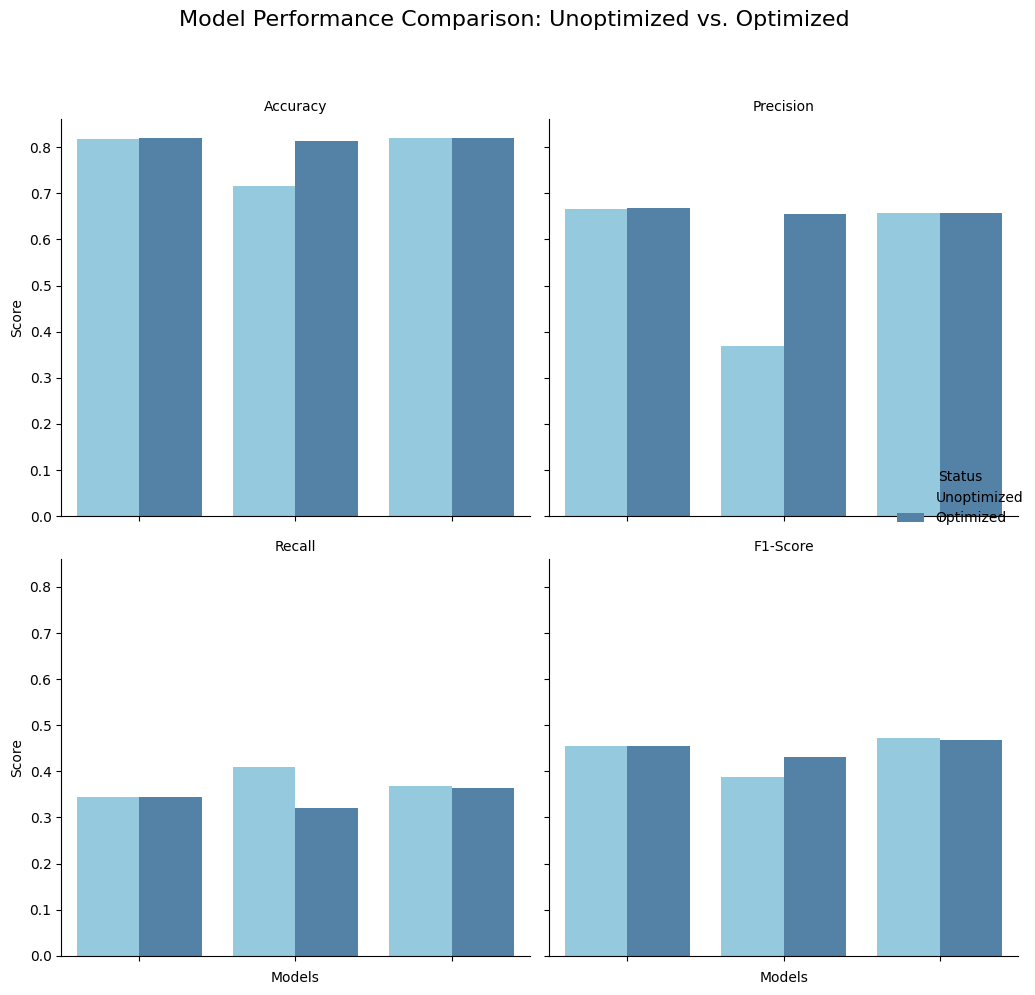

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Prepare data for plotting - reshape the combined_performance_df for easier plotting
# We want groups for each model type (e.g., Logistic Regression), and within each group,
# bars for unoptimized vs. optimized for each metric.

# First, let's extract the model names without the (Unoptimized)/(Optimized) suffix
model_types = ['Logistic Regression', 'Decision Tree', 'Random Forest']
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

# Create a more structured DataFrame for plotting
plot_df = pd.DataFrame()

for model_type in model_types:
    unoptimized_row = combined_performance_df.loc[f'{model_type} (Unoptimized)']
    optimized_row = combined_performance_df.loc[f'{model_type} (Optimized)']

    for metric in metrics:
        plot_df = pd.concat([plot_df, pd.DataFrame({
            'Model': [model_type],
            'Metric': [metric],
            'Performance': [unoptimized_row[metric]],
            'Status': ['Unoptimized']
        })])
        plot_df = pd.concat([plot_df, pd.DataFrame({
            'Model': [model_type],
            'Metric': [metric],
            'Performance': [optimized_row[metric]],
            'Status': ['Optimized']
        })])

# Use sns.catplot for faceting by Metric
g = sns.catplot(x='Model', y='Performance', hue='Status', col='Metric', data=plot_df,
                kind='bar', palette={'Unoptimized': 'skyblue', 'Optimized': 'steelblue'},
                height=5, aspect=0.9, col_wrap=2, legend_out=True)

g.set_axis_labels("Models", "Score")
g.set_titles("{col_name}")
g.set_xticklabels(rotation=30, ha="right")
g.fig.suptitle('Model Performance Comparison: Unoptimized vs. Optimized', y=1.02, fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent suptitle overlap
plt.show()

### Comparison of Optimized Models

After hyperparameter tuning, we can observe the following improvements and comparisons between the models:

*   **Logistic Regression**: Hyperparameter tuning improved its F1-Score slightly from 0.4540 to 0.4550. Its precision remained high (0.6681), suggesting it continues to be good at minimizing false positives.

*   **Decision Tree**: This model showed the most significant change. While its unoptimized F1-score was 0.3874, the optimized version achieved an F1-Score of 0.4305. The optimized Decision Tree also saw a substantial increase in precision (from 0.3681 to 0.6547) but a decrease in recall (from 0.4090 to 0.3206). This indicates that the tuning made the Decision Tree more conservative, predicting fewer defaults but with higher confidence.

*   **Random Forest**: The Random Forest model's F1-Score slightly decreased from 0.4717 (unoptimized) to 0.4679 (optimized) on the test set, although its cross-validated F1-score was higher during GridSearchCV. Its accuracy remained similar, and precision was also comparable to the unoptimized version.

**Overall Best Performing Model After Optimization:**

Comparing the optimized models, **Random Forest** still exhibits the highest F1-Score (0.4679) on the test set, indicating the best balance between precision and recall for this problem. Logistic Regression follows closely with an F1-Score of 0.4550. The Decision Tree, despite significant improvement, still lags behind.

It's important to note that while Random Forest had the highest F1-score, Logistic Regression maintained very competitive performance, especially in terms of precision, which might be a critical metric depending on the business cost of false positives in credit default prediction.

### Comparison of Optimized Models

After hyperparameter tuning, we can observe the following improvements and comparisons between the models:

*   **Logistic Regression**: Hyperparameter tuning improved its F1-Score slightly from 0.4540 to 0.4550. Its precision remained high (0.6681), suggesting it continues to be good at minimizing false positives.

*   **Decision Tree**: This model showed the most significant change. While its unoptimized F1-score was 0.3874, the optimized version achieved an F1-Score of 0.4305. The optimized Decision Tree also saw a substantial increase in precision (from 0.3681 to 0.6547) but a decrease in recall (from 0.4090 to 0.3206). This indicates that the tuning made the Decision Tree more conservative, predicting fewer defaults but with higher confidence.

*   **Random Forest**: The Random Forest model's F1-Score slightly decreased from 0.4717 (unoptimized) to 0.4679 (optimized) on the test set, although its cross-validated F1-score was higher during GridSearchCV. Its accuracy remained similar, and precision was also comparable to the unoptimized version.

**Overall Best Performing Model After Optimization:**

Comparing the optimized models, **Random Forest** still exhibits the highest F1-Score (0.4679) on the test set, indicating the best balance between precision and recall for this problem. Logistic Regression follows closely with an F1-Score of 0.4550. The Decision Tree, despite significant improvement, still lags behind.

It's important to note that while Random Forest had the highest F1-score, Logistic Regression maintained very competitive performance, especially in terms of precision, which might be a critical metric depending on the business cost of false positives in credit default prediction.

## Final Task

### Subtask:
Summarize the hyperparameter optimization process, including the methods used, the best parameters found, and the impact on model performance.


## Summary:

### Q&A
Hyperparameter optimization is the process of systematically searching for the optimal set of hyperparameters for a machine learning model to achieve the best possible performance on a given task. It is crucial because hyperparameters directly impact how a model learns, influencing its performance, preventing issues like overfitting and underfitting, improving predictive accuracy, and optimizing model complexity.

### Data Analysis Key Findings
*   **Hyperparameter Grids Defined**: Specific hyperparameter ranges were defined for each model:
    *   **Logistic Regression**: `C` (\[0.001, 0.01, 0.1, 1, 10, 100]) and `penalty` (\[`l1`, `l2`]).
    *   **Decision Tree**: `max_depth` (\[None, 10, 20, 30]), `min_samples_split` (\[2, 5, 10]), `min_samples_leaf` (\[1, 2, 4]), and `criterion` (\[`gini`, `entropy`]).
    *   **Random Forest**: `n_estimators` (\[50, 100, 200]), `max_depth` (\[None, 10, 20]), `min_samples_split` (\[2, 5]), `min_samples_leaf` (\[1, 2]), and `criterion` (\[`gini`, `entropy`]).
*   **Hyperparameter Tuning Results (GridSearchCV, F1-Score on training data with cross-validation)**:
    *   **Logistic Regression**: Best parameters were `{'C': 1, 'penalty': 'l1'}` with an F1-Score of 0.4706.
    *   **Decision Tree**: Best parameters were `{'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 2}` with an F1-Score of 0.4535.
    *   **Random Forest**: Best parameters were `{'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}` with an F1-Score of 0.4755.
*   **Optimized Model Performance on Test Set**:
    *   **Logistic Regression**: Achieved an F1-Score of 0.4550 (Accuracy: 0.8192, Precision: 0.6681, Recall: 0.3450). This was a slight improvement from its unoptimized F1-score of 0.4540.
    *   **Decision Tree**: Achieved an F1-Score of 0.4305 (Accuracy: 0.8143, Precision: 0.6547, Recall: 0.3206). This was a significant improvement from its unoptimized F1-score of 0.3874, with a notable increase in precision (from 0.3681 to 0.6547) but a decrease in recall (from 0.4090 to 0.3206).
    *   **Random Forest**: Achieved an F1-Score of 0.4679 (Accuracy: 0.8192, Precision: 0.6570, Recall: 0.3633). This was a slight decrease from its unoptimized F1-score of 0.4717 on the test set.
*   **Best Overall Optimized Model**: The Random Forest model, even with a slight drop in test F1-score after optimization, remained the best performer with an F1-Score of 0.4679, closely followed by Logistic Regression.

### Insights or Next Steps
*   **Focus on Random Forest and Logistic Regression**: Given that Random Forest and Logistic Regression consistently show the highest F1-scores, further efforts could be concentrated on these models, potentially exploring more advanced ensemble techniques or feature engineering to boost their performance.
*   **Re-evaluate Decision Tree Optimization Strategy**: While the Decision Tree showed a substantial F1-score improvement (0.3874 to 0.4305), the trade-off between precision and recall (increased precision, decreased recall) suggests that the current optimization strategy might be too conservative. Further tuning could aim for a better balance, potentially by adjusting the `refit` metric in `GridSearchCV` or using a different search strategy.
